# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# # 🎬 Sparkle Movie 2 — Notebook 1 : Exploration des Données (EDA)
#
# **Objectif** : Explorer et comprendre le dataset MovieLens enrichi avec
# les métadonnées TMDB, afin de préparer la modélisation des moteurs de
# recommandation.
#
# **Sources de données** :
# - `ratings.parquet`      → Notes des utilisateurs (userId, movieId, rating, timestamp)
# - `movies_enriched.parquet` → Films MovieLens + métadonnées TMDB
#
# **Plan du notebook** :
# 1. Configuration & chargement
# 2. Qualité des données
# 3. Analyse de la matrice de notation (sparsité)
# 4. Distribution des notes
# 5. Activité des utilisateurs
# 6. Activité des films
# 7. Top films
# 8. Analyse des genres
# 9. Évolution temporelle
# 10. Données financières & popularité TMDB
# 11. Synthèse & conclusions


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 1. Configuration & Chargement


In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, FloatType

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# ── Session Spark ─────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("sparkle-movie-eda")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "8")   # réduit pour usage local
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} démarré")


✅ Spark 4.1.1 démarré


In [3]:
# ── Chargement des données ────────────────────────────────────────────────────
DATA_DIR = "../data/enriched"

ratings         = spark.read.parquet(f"{DATA_DIR}/ratings.parquet")
movies_enriched = spark.read.parquet(f"{DATA_DIR}/movies_enriched.parquet")

# Mise en cache (utilisés dans toutes les sections suivantes)
ratings.cache()
movies_enriched.cache()

print("✅ Données chargées")


✅ Données chargées


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 2. Qualité des données
# Avant toute analyse, on vérifie l'intégrité des deux tables :
# valeurs manquantes, doublons, cohérence des types.


In [4]:
# ── Schéma ────────────────────────────────────────────────────────────────────
print("── RATINGS ──")
ratings.printSchema()
ratings.show(5)

print("── MOVIES ENRICHED ──")
movies_enriched.printSchema()
movies_enriched.show(5, truncate=60)


── RATINGS ──
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|     80|   5.0|944248943|
|     1|    110|   3.0|943231119|
|     1|    562|   5.0|944082810|
|     1|    608|   2.0|944248943|
|     1|    645|   4.0|944253272|
+------+-------+------+---------+
only showing top 5 rows
── MOVIES ENRICHED ──
root
 |-- tmdbId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- year_movielens: integer (nullable = true)
 |-- title_clean: string (nullable = true)
 |-- imdbId: integer (nullable = true)
 |-- media_type: string (nullable = true)
 |-- title_fr: string (nullable = true)
 |-- original_title: string (nullable = true)
 |-- tagline: string (nullable = true)
 |-- overview:

In [5]:
# ── Dimensions ───────────────────────────────────────────────────────────────
nb_ratings  = ratings.count()
nb_users    = ratings.select("userId").distinct().count()
nb_movies_r = ratings.select("movieId").distinct().count()
nb_movies_m = movies_enriched.count()

print(f"📊 Ratings    : {nb_ratings:,} notes")
print(f"👤 Utilisateurs : {nb_users:,}")
print(f"🎬 Films (ratings)        : {nb_movies_r:,}")
print(f"🎬 Films (movies_enriched): {nb_movies_m:,}")


📊 Ratings    : 32,000,204 notes
👤 Utilisateurs : 200,948
🎬 Films (ratings)        : 84,432
🎬 Films (movies_enriched): 87,585


In [18]:
# ── Valeurs manquantes ────────────────────────────────────────────────────────
print("── Valeurs manquantes — ratings ──")
for col in ratings.columns:
    n_null = ratings.filter(F.col(col).isNull()).count()
    pct    = round(n_null / nb_ratings * 100, 1)
    print(f"  {col:15s} → {n_null:,} nulls ({pct}%)")

print("\n── Valeurs manquantes — movies_enriched (colonnes clés) ──")
cols_to_check = [
    "movieId", "tmdbId", "imdbId",
    "title_clean", "title_fr", "overview", "keywords",
    "genres", "genres_tmdb", "directors", "cast_top10",
    "release_date", "runtime", "original_lang",
    "prod_countries", "collection",
    "vote_average", "vote_count", "budget", "revenue",
    "certification_us", "similar_ids",
]

# Récupère les colonnes STRING du DataFrame
string_cols = {
    f.name for f in movies_enriched.schema.fields
    if str(f.dataType) == "StringType()"
}

for col in cols_to_check:
    if col not in movies_enriched.columns:
        continue

    if col in string_cols:
        # Colonne texte → null OU chaîne vide
        cond = F.col(col).isNull() | (F.col(col) == "")
    else:
        # Colonne numérique → null uniquement
        cond = F.col(col).isNull()

    n_null = movies_enriched.filter(cond).count()
    pct    = round(n_null / nb_movies_m * 100, 1)
    flag   = " ⚠️" if pct > 20 else ""
    print(f"  {col:25s} → {n_null:,} nulls ({pct}%){flag}")


── Valeurs manquantes — ratings ──
  userId          → 0 nulls (0.0%)
  movieId         → 0 nulls (0.0%)
  rating          → 0 nulls (0.0%)
  timestamp       → 0 nulls (0.0%)

── Valeurs manquantes — movies_enriched (colonnes clés) ──
  movieId                   → 0 nulls (0.0%)
  tmdbId                    → 124 nulls (0.1%)
  imdbId                    → 0 nulls (0.0%)
  title_clean               → 1 nulls (0.0%)
  title_fr                  → 507 nulls (0.6%)
  overview                  → 38,307 nulls (43.7%) ⚠️
  keywords                  → 25,225 nulls (28.8%) ⚠️
  genres                    → 0 nulls (0.0%)
  genres_tmdb               → 1,476 nulls (1.7%)
  directors                 → 1,401 nulls (1.6%)
  cast_top10                → 3,905 nulls (4.5%)
  release_date              → 641 nulls (0.7%)
  runtime                   → 1,343 nulls (1.5%)
  original_lang             → 507 nulls (0.6%)
  prod_countries            → 5,251 nulls (6.0%)
  vote_average              → 507 nulls (0.6

In [19]:
# ── Nettoyage post-analyse ────────────────────────────────────────────────────

# 1. Drop des colonnes à faible valeur prédictive
cols_to_drop = ["certification_us", "certification_fr", "real_tmdb_id"]
cols_to_drop = [c for c in cols_to_drop if c in movies_enriched.columns]
if cols_to_drop:
    movies_enriched = movies_enriched.drop(*cols_to_drop)

# 2. Binariser collection → seulement si la colonne existe encore
if "collection" in movies_enriched.columns:
    movies_enriched = movies_enriched.withColumn(
        "in_collection",
        F.when(F.col("collection").isNull(), 0).otherwise(1)
    ).drop("collection")

# 3. Idem pour collection_id (redondant avec in_collection)
if "collection_id" in movies_enriched.columns:
    movies_enriched = movies_enriched.drop("collection_id")

# Mise à jour du cache
movies_enriched.unpersist()
movies_enriched.cache()

print("✅ Nettoyage effectué")
print(f"   Colonnes restantes : {len(movies_enriched.columns)}")
print(f"   {movies_enriched.columns}")



✅ Nettoyage effectué
   Colonnes restantes : 40
   ['tmdbId', 'movieId', 'title', 'genres', 'year_movielens', 'title_clean', 'imdbId', 'media_type', 'title_fr', 'original_title', 'tagline', 'overview', 'keywords', 'release_date', 'runtime', 'status', 'adult', 'original_lang', 'origin_countries', 'prod_countries', 'spoken_languages', 'budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'genres_tmdb', 'directors', 'writers', 'composers', 'producers', 'cinematographer', 'cast_top10', 'cast_characters', 'studios', 'similar_ids', 'recommended_ids', 'poster_path', 'backdrop_path', 'in_collection']


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 3. Analyse de la matrice de notation
#
# La **sparsité** mesure le pourcentage de cases vides dans la matrice
# utilisateurs × films. C'est un indicateur fondamental pour ALS :
# une sparsité proche de 100% est normale et attendue.
#
# $$\text{Sparsité} = 1 - \frac{\text{notes existantes}}{\text{utilisateurs} \times \text{films}}$$


In [23]:
# ── Calcul de la sparsité ─────────────────────────────────────────────────────
numerator   = ratings.count()
denominator = nb_users * nb_movies_r
sparsity    = 1 - (numerator / denominator)
density     = 1 - sparsity  # = numerator / denominator

print(f"Nombre de notes    : {numerator:,}")
print(f"Matrice théorique  : {nb_users:,} × {nb_movies_r:,} = {denominator:,}")
print(f"Sparsité           : {sparsity:.4%}")
print()
print(f"→ Seulement {density:.4%} de la matrice est remplie.")
print("→ Une sparsité élevée est normale : un utilisateur ne peut pas")
print("  avoir vu tous les films. C'est précisément ce qu'ALS est conçu pour gérer.")


Nombre de notes    : 32,000,204
Matrice théorique  : 200,948 × 84,432 = 16,966,441,536
Sparsité           : 99.8114%

→ Seulement 0.1886% de la matrice est remplie.
→ Une sparsité élevée est normale : un utilisateur ne peut pas
  avoir vu tous les films. C'est précisément ce qu'ALS est conçu pour gérer.


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 4. Distribution des notes
#
# Les notes vont de 0.5 à 5.0 par pas de 0.5.
# On analyse leur répartition pour détecter des biais (notes trop positives,
# absence de certaines valeurs, etc.).


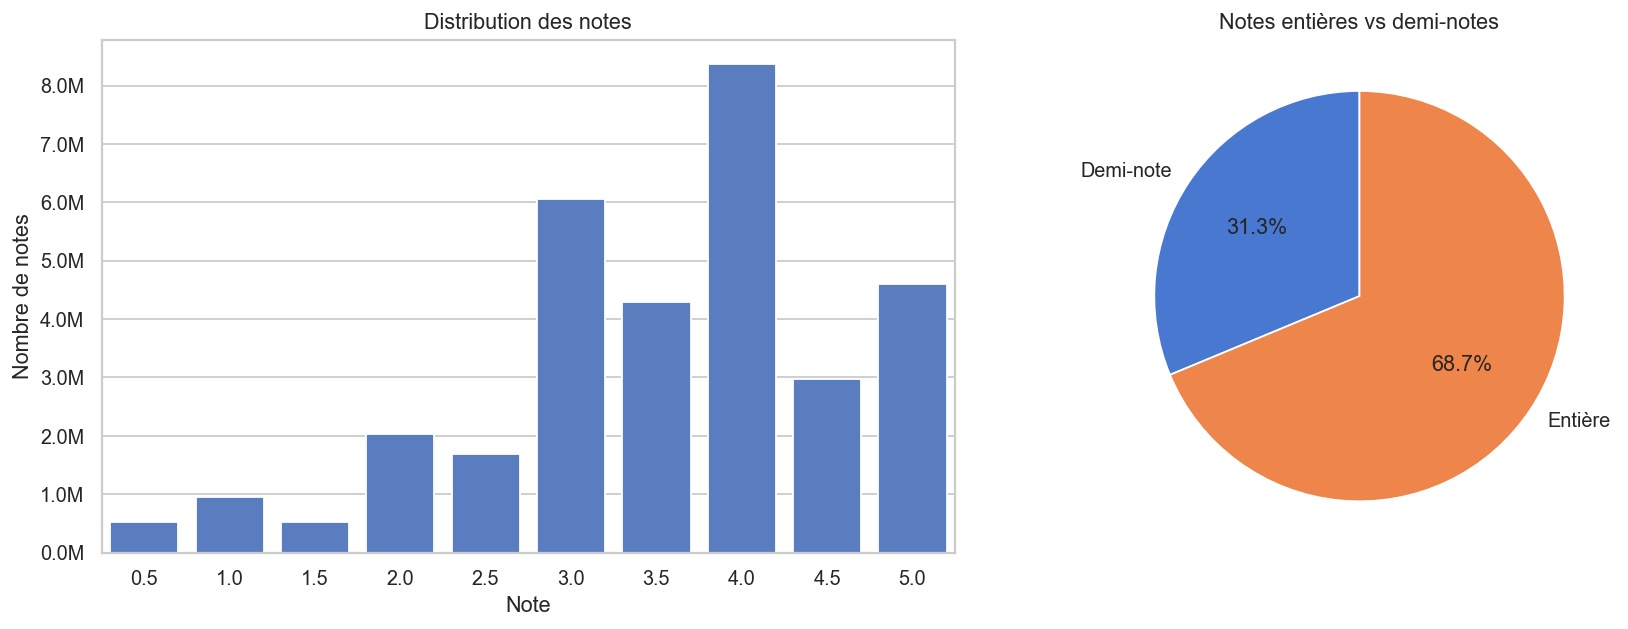

In [21]:
# ── Distribution ─────────────────────────────────────────────────────────────
rating_dist = (
    ratings.groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot principal
sns.barplot(data=rating_dist, x="rating", y="count", ax=axes[0])
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de notes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Notes entières vs demi-notes
rating_dist["type"] = rating_dist["rating"].apply(
    lambda r: "Entière" if r % 1 == 0 else "Demi-note"
)
type_dist = rating_dist.groupby("type")["count"].sum().reset_index()
axes[1].pie(type_dist["count"], labels=type_dist["type"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Notes entières vs demi-notes")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_distribution_notes.png", bbox_inches="tight")
plt.show()


In [22]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
ratings.select(
    F.mean("rating").alias("Moyenne"),
    F.stddev("rating").alias("Écart-type"),
    F.min("rating").alias("Min"),
    F.percentile_approx("rating", 0.25).alias("Q1"),
    F.percentile_approx("rating", 0.5).alias("Médiane"),
    F.percentile_approx("rating", 0.75).alias("Q3"),
    F.max("rating").alias("Max"),
).show()

# Proportion de notes "positives" (>= 3.5)
n_positives = ratings.filter(F.col("rating") >= 3.5).count()
print(f"Notes >= 3.5 : {n_positives/nb_ratings:.1%} des notes")
print("→ Les utilisateurs ont tendance à noter positivement (biais de sélection :")
print("  on regarde surtout les films qu'on pense apprécier).")


+------------------+------------------+---+---+-------+---+---+
|           Moyenne|        Écart-type|Min| Q1|Médiane| Q3|Max|
+------------------+------------------+---+---+-------+---+---+
|3.5403956487277393|1.0589862139453061|0.5|3.0|    3.5|4.0|5.0|
+------------------+------------------+---+---+-------+---+---+

Notes >= 3.5 : 63.2% des notes
→ Les utilisateurs ont tendance à noter positivement (biais de sélection :
  on regarde surtout les films qu'on pense apprécier).


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 5. Activité des utilisateurs
#
# On analyse combien de films chaque utilisateur a noté.
# Cela permet d'identifier les utilisateurs très actifs vs les utilisateurs
# froids (**cold start**), problème critique pour les systèmes de recommandation.


In [24]:
# ── Nb de notes par utilisateur ───────────────────────────────────────────────
ratings_per_user = (
    ratings.groupBy("userId")
    .count()
    .withColumnRenamed("count", "nb_ratings")
)

user_stats = ratings_per_user.select(
    F.mean("nb_ratings").alias("Moyenne"),
    F.stddev("nb_ratings").alias("Écart-type"),
    F.min("nb_ratings").alias("Min"),
    F.percentile_approx("nb_ratings", 0.25).alias("Q1"),
    F.percentile_approx("nb_ratings", 0.5).alias("Médiane"),
    F.percentile_approx("nb_ratings", 0.75).alias("Q3"),
    F.max("nb_ratings").alias("Max"),
).toPandas()
print(user_stats.T)


                       0
Moyenne       159.246193
Écart-type    282.025462
Min            20.000000
Q1             36.000000
Médiane        73.000000
Q3            167.000000
Max         33332.000000


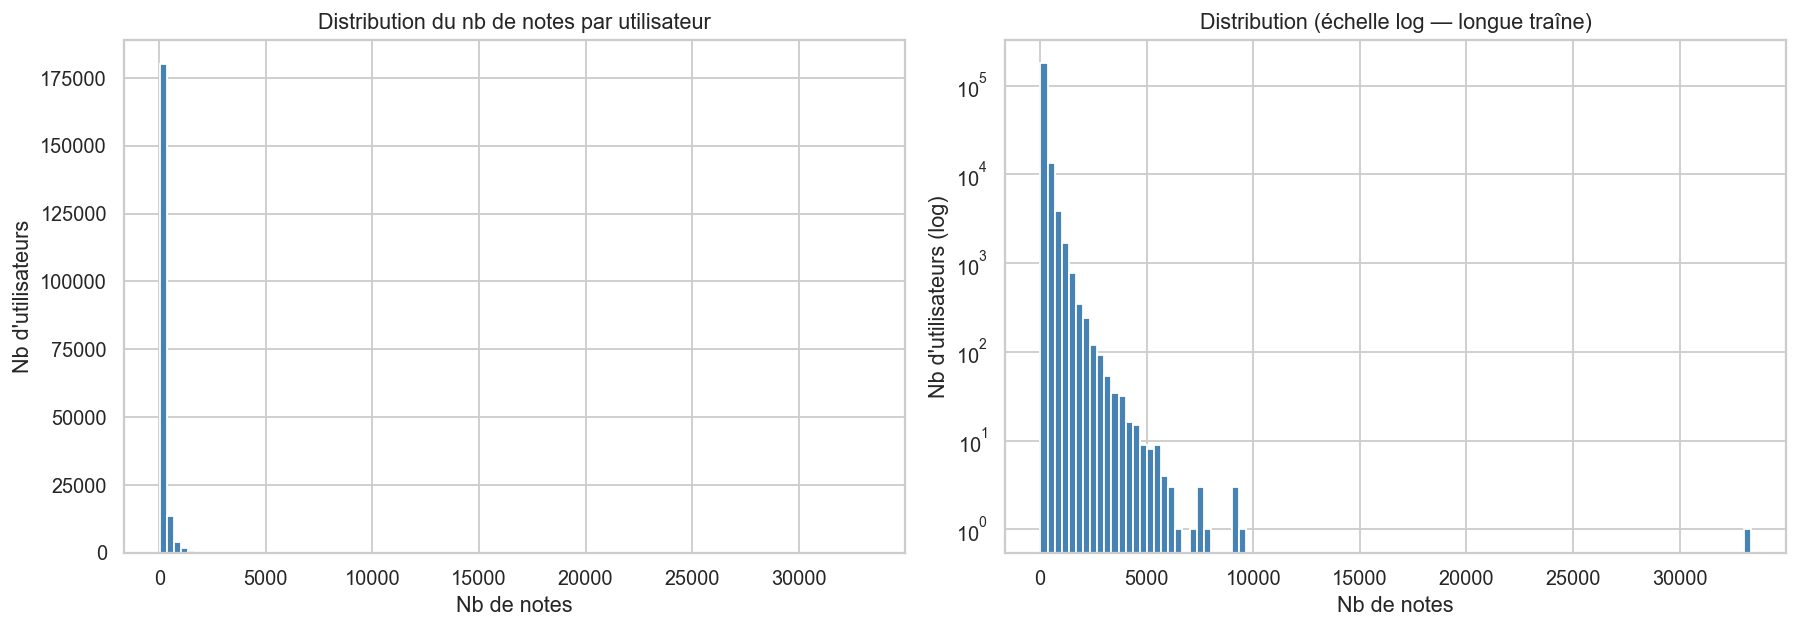

In [28]:
# ── Visualisation (log scale pour la longue traîne) ───────────────────────────
user_pd = ratings_per_user.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_pd["nb_ratings"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du nb de notes par utilisateur")
axes[0].set_xlabel("Nb de notes")
axes[0].set_ylabel("Nb d'utilisateurs")

axes[1].hist(user_pd["nb_ratings"], bins=100, color="steelblue", edgecolor="white", log=True)
axes[1].set_title("Distribution (échelle log — longue traîne)")
axes[1].set_xlabel("Nb de notes")
axes[1].set_ylabel("Nb d'utilisateurs (log)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_activite_utilisateurs.png", bbox_inches="tight")
plt.show()


In [29]:
# ── Cold start : utilisateurs avec très peu de notes ─────────────────────────
for seuil in [5, 10, 20]:
    n = ratings_per_user.filter(F.col("nb_ratings") < seuil).count()
    print(f"Utilisateurs avec < {seuil} notes : {n:,} ({n/nb_users:.1%})")

print("\n→ Ces utilisateurs sont difficiles à recommander (cold start).")
print("→ ALS les gère via la régularisation, mais leur précision sera plus faible.")


Utilisateurs avec < 5 notes : 0 (0.0%)
Utilisateurs avec < 10 notes : 0 (0.0%)
Utilisateurs avec < 20 notes : 0 (0.0%)

→ Ces utilisateurs sont difficiles à recommander (cold start).
→ ALS les gère via la régularisation, mais leur précision sera plus faible.


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 6. Activité des films
#
# Même analyse côté films : combien de fois chaque film a été noté ?
# Les films peu notés seront aussi concernés par le cold start.


In [30]:
# ── Nb de notes par film ──────────────────────────────────────────────────────
ratings_per_movie = (
    ratings.groupBy("movieId")
    .agg(
        F.count("rating").alias("nb_ratings"),
        F.mean("rating").alias("avg_rating")
    )
)

movie_stats = ratings_per_movie.select(
    F.mean("nb_ratings").alias("Moyenne"),
    F.min("nb_ratings").alias("Min"),
    F.percentile_approx("nb_ratings", 0.5).alias("Médiane"),
    F.max("nb_ratings").alias("Max"),
).toPandas()
print(movie_stats.T)


                     0
Moyenne     379.005638
Min           1.000000
Médiane       5.000000
Max      102929.000000


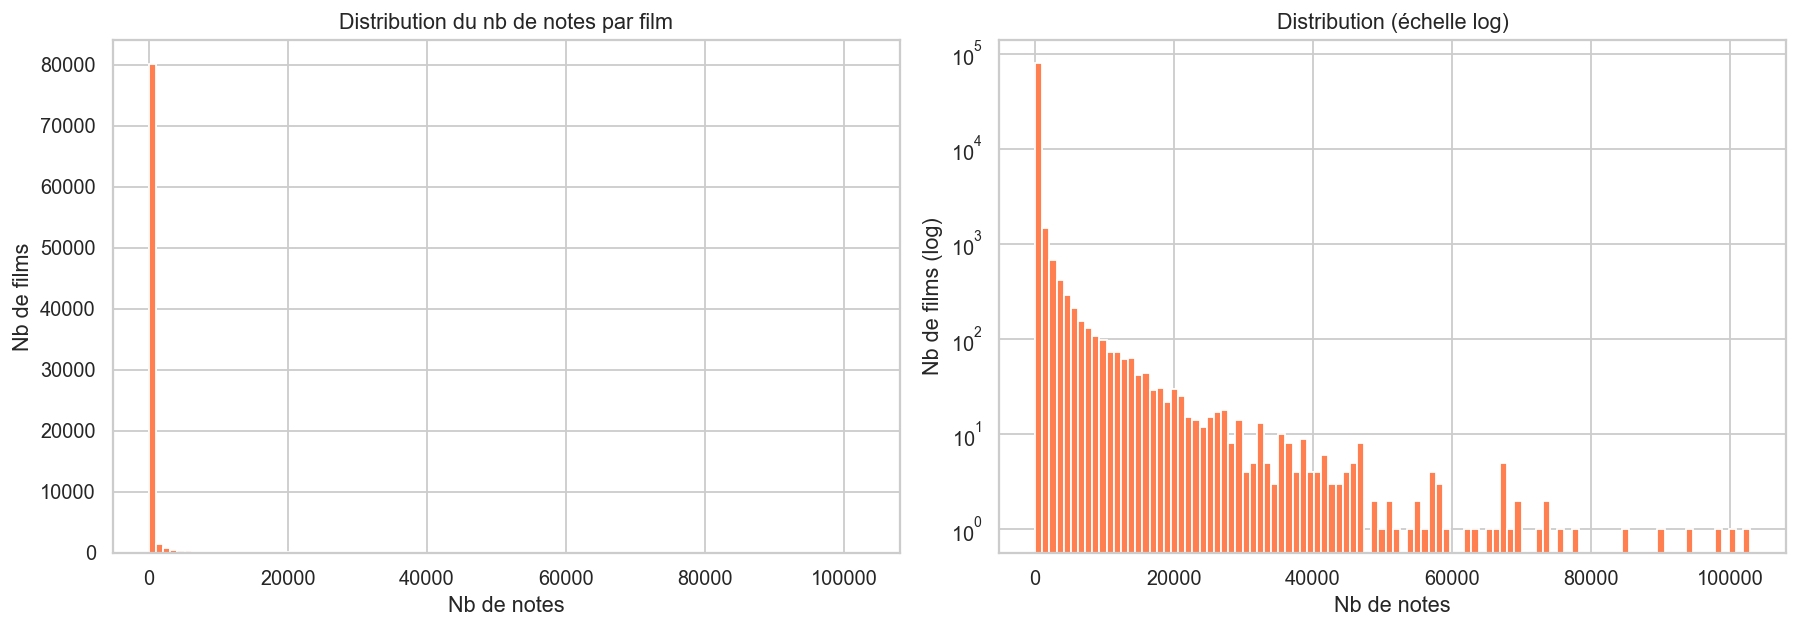

Films avec < 5 notes : 40,548 (48.0%)
Films avec < 10 notes : 52,471 (62.1%)
Films avec < 50 notes : 68,398 (81.0%)


In [31]:
# ── Visualisation ─────────────────────────────────────────────────────────────
movie_pd = ratings_per_movie.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(movie_pd["nb_ratings"], bins=100, color="coral", edgecolor="white")
axes[0].set_title("Distribution du nb de notes par film")
axes[0].set_xlabel("Nb de notes")
axes[0].set_ylabel("Nb de films")

axes[1].hist(movie_pd["nb_ratings"], bins=100, color="coral", edgecolor="white", log=True)
axes[1].set_title("Distribution (échelle log)")
axes[1].set_xlabel("Nb de notes")
axes[1].set_ylabel("Nb de films (log)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_activite_films.png", bbox_inches="tight")
plt.show()

for seuil in [5, 10, 50]:
    n = ratings_per_movie.filter(F.col("nb_ratings") < seuil).count()
    print(f"Films avec < {seuil} notes : {n:,} ({n/nb_movies_r:.1%})")


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 7. Top films
#
# On identifie les films les mieux notés, avec un **seuil minimal de votes**
# pour éviter qu'un film avec 1 seule note de 5/5 apparaisse en tête.
# Ce seuil correspond au percentile 75 du nb de notes par film.


In [32]:
# ── Calcul du seuil ───────────────────────────────────────────────────────────
SEUIL = int(
    ratings_per_movie
    .select(F.percentile_approx("nb_ratings", 0.75))
    .collect()[0][0]
)
print(f"Seuil minimal retenu (P75) : {SEUIL} notes")


Seuil minimal retenu (P75) : 25 notes


In [39]:
# ── Top 20 films ──────────────────────────────────────────────────────────────
top_movies = (
    ratings_per_movie
    .filter(F.col("nb_ratings") >= SEUIL)
    .join(
        movies_enriched.select("movieId", "title_clean", "genres", "year_movielens"),
        on="movieId", how="left"
    )
    .filter(
        F.col("year_movielens").isNotNull() &
        F.col("genres").isNotNull() &
        (F.col("genres") != "(no genres listed)")
    )
    .select("title_clean", "year_movielens", "genres", "nb_ratings", "avg_rating")
    .orderBy(F.col("avg_rating").desc())
    .limit(20)
)
top_movies.show(20, truncate=50)


+------------------------------------+--------------+---------------------------+----------+------------------+
|                         title_clean|year_movielens|                     genres|nb_ratings|        avg_rating|
+------------------------------------+--------------+---------------------------+----------+------------------+
|                     Planet Earth II|          2016|                Documentary|      1956|4.4468302658486705|
|                        Planet Earth|          2006|                Documentary|      2948| 4.444369063772049|
|                    Band of Brothers|          2001|           Action|Drama|War|      2811| 4.426538598363572|
|           Shawshank Redemption, The|          1994|                Crime|Drama|    102929| 4.404613860039444|
|                      Godfather, The|          1972|                Crime|Drama|     66440| 4.317030403371463|
|                            Parasite|          2019|               Comedy|Drama|     11670| 4.312253641

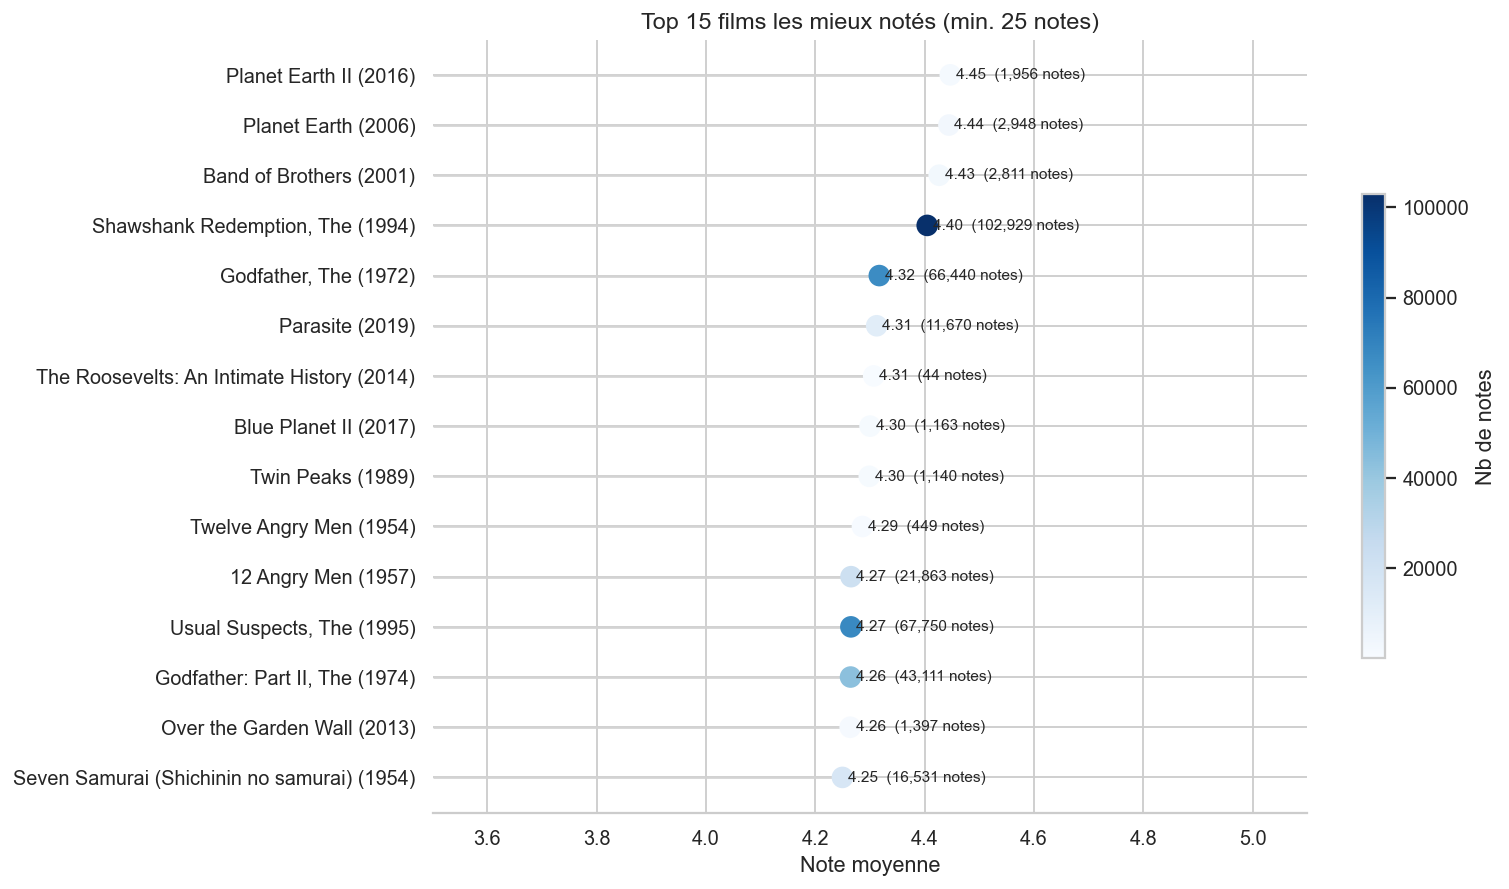

In [40]:
# ── Visualisation Top 15 — Lollipop + nb de notes en couleur ─────────────────
top_pd = top_movies.toPandas().head(15).iloc[::-1].reset_index(drop=True)
top_pd["label"] = top_pd["title_clean"] + " (" + top_pd["year_movielens"].astype(str) + ")"

fig, ax = plt.subplots(figsize=(12, 7))

# Positions numériques (évite le bug hlines + axe catégoriel)
y_pos  = np.arange(len(top_pd))
norm   = plt.Normalize(top_pd["nb_ratings"].min(), top_pd["nb_ratings"].max())
cmap   = plt.cm.Blues
colors = cmap(norm(top_pd["nb_ratings"]))

# Tiges
ax.hlines(y=y_pos, xmin=3.5, xmax=top_pd["avg_rating"].values,
          color="lightgrey", linewidth=1.5, zorder=1)

# Points
ax.scatter(top_pd["avg_rating"], y_pos, color=colors, s=120, zorder=2)

# Valeurs
for i, row in top_pd.iterrows():
    ax.text(row["avg_rating"] + 0.01, i,
            f'{row["avg_rating"]:.2f}  ({int(row["nb_ratings"]):,} notes)',
            va="center", fontsize=8.5)

# Labels Y
ax.set_yticks(y_pos)
ax.set_yticklabels(top_pd["label"])

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Nb de notes", shrink=0.6)

ax.set_xlim(3.5, 5.1)
ax.set_title(f"Top 15 films les mieux notés (min. {SEUIL} notes)", fontsize=13)
ax.set_xlabel("Note moyenne")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_top_films.png", bbox_inches="tight")
plt.show()


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 8. Analyse des genres
#
# Les genres MovieLens sont stockés sous forme `"Action|Adventure|Comedy"`.
# On les explose pour analyser la popularité et la qualité perçue par genre.


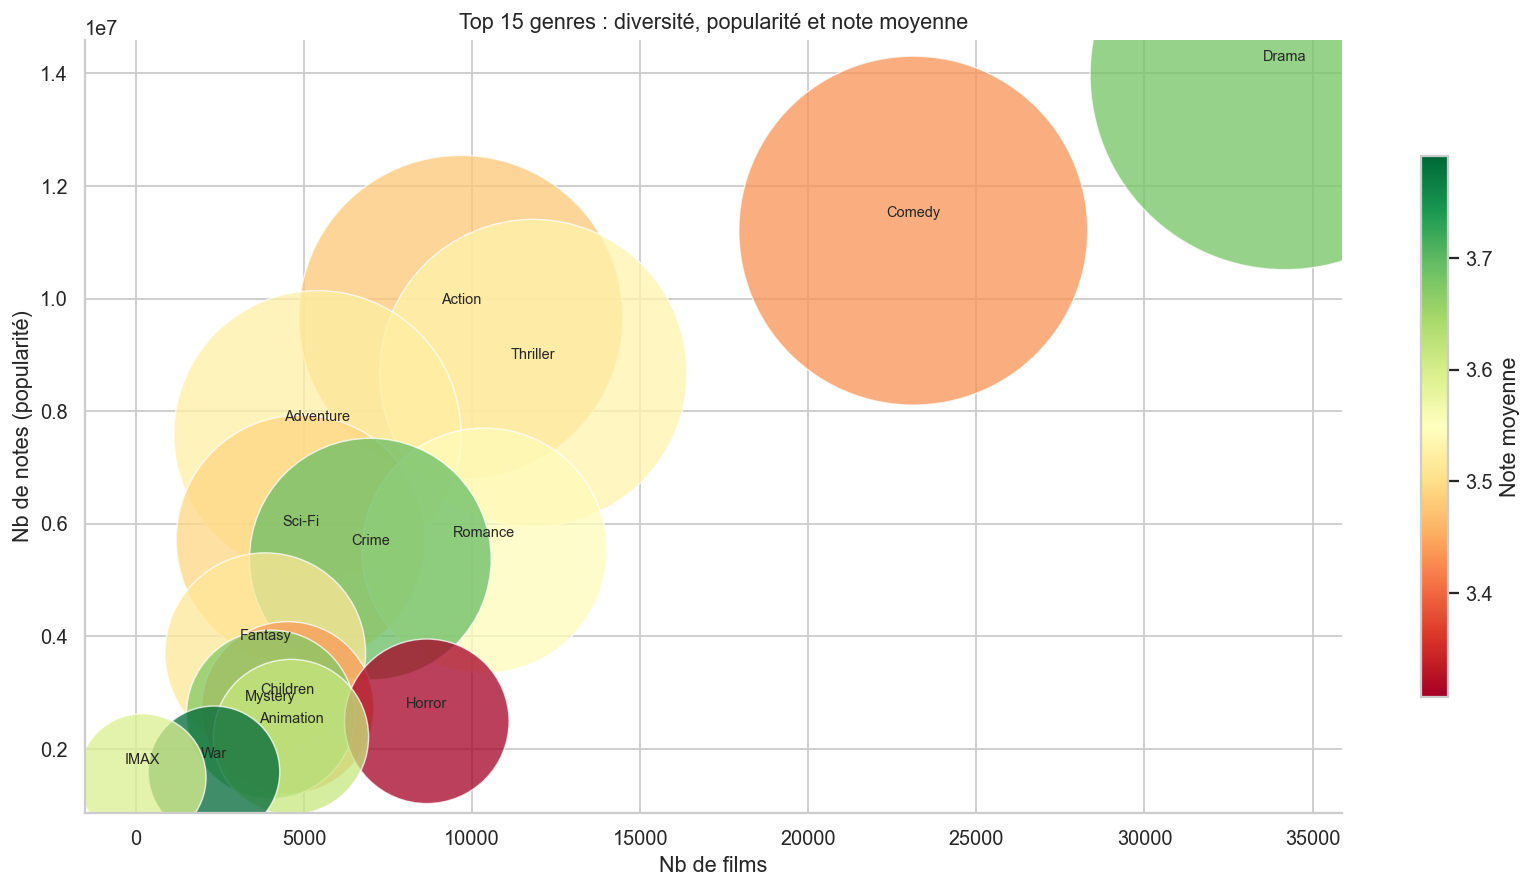

In [48]:
# ── Visualisation genres — Bubble chart ──────────────────────────────────────
genre_top15 = genre_stats.head(15)   # déjà trié par nb_ratings desc

fig, ax = plt.subplots(figsize=(13, 7))

norm   = plt.Normalize(genre_top15["avg_rating"].min(), genre_top15["avg_rating"].max())
cmap   = plt.cm.RdYlGn
colors = cmap(norm(genre_top15["avg_rating"]))

ax.scatter(
    genre_top15["nb_films"],
    genre_top15["nb_ratings"],
    s=genre_top15["nb_ratings"] / 300,
    c=colors,
    alpha=0.75,
    edgecolors="white",
    linewidths=0.8
)

for _, row in genre_top15.iterrows():
    ax.annotate(
        row["genre"],
        (row["nb_films"], row["nb_ratings"]),
        fontsize=8, ha="center", va="bottom",
        xytext=(0, 6), textcoords="offset points"
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Note moyenne", shrink=0.7)

ax.set_xlabel("Nb de films")
ax.set_ylabel("Nb de notes (popularité)")
ax.set_title("Top 15 genres : diversité, popularité et note moyenne")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_genres.png", bbox_inches="tight")
plt.show()


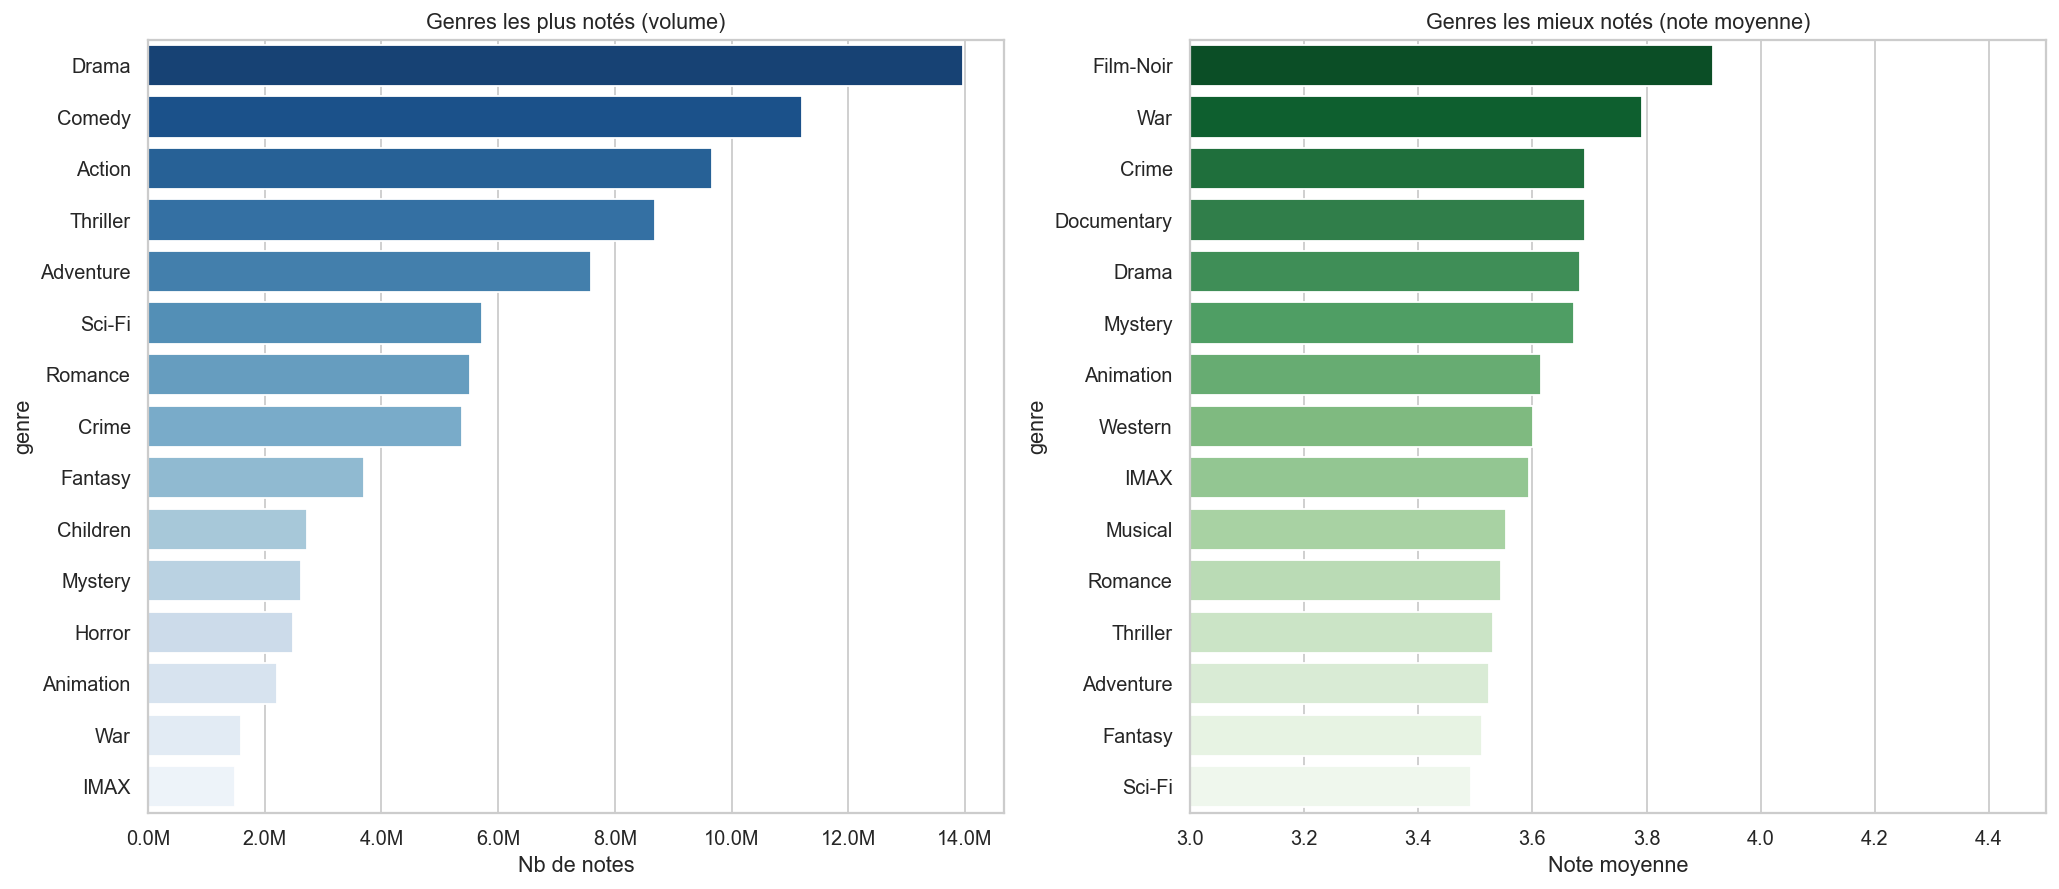

In [43]:
# ── Visualisation double ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Volume de notes par genre
top_genre = genre_stats.head(15)
sns.barplot(data=top_genre, y="genre", x="nb_ratings", ax=axes[0], palette="Blues_r")
axes[0].set_title("Genres les plus notés (volume)")
axes[0].set_xlabel("Nb de notes")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Note moyenne par genre (trié)
genre_sorted = genre_stats.sort_values("avg_rating", ascending=False).head(15)
sns.barplot(data=genre_sorted, y="genre", x="avg_rating", ax=axes[1],
            palette="Greens_r")
axes[1].set_title("Genres les mieux notés (note moyenne)")
axes[1].set_xlabel("Note moyenne")
axes[1].set_xlim(3.0, 4.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_genres.png", bbox_inches="tight")
plt.show()


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 9. Évolution temporelle
#
# On analyse comment l'activité de notation et la qualité perçue
# ont évolué dans le temps. Le timestamp MovieLens est en Unix time (secondes).


In [49]:
# ── Conversion timestamp → année ──────────────────────────────────────────────
ratings_time = (
    ratings
    .withColumn("date", F.from_unixtime(F.col("timestamp")).cast("date"))
    .withColumn("year", F.year("date"))
    .withColumn("month", F.month("date"))
)

yearly = (
    ratings_time.groupBy("year")
    .agg(
        F.count("rating").alias("nb_ratings"),
        F.mean("rating").alias("avg_rating")
    )
    .orderBy("year")
    .toPandas()
)


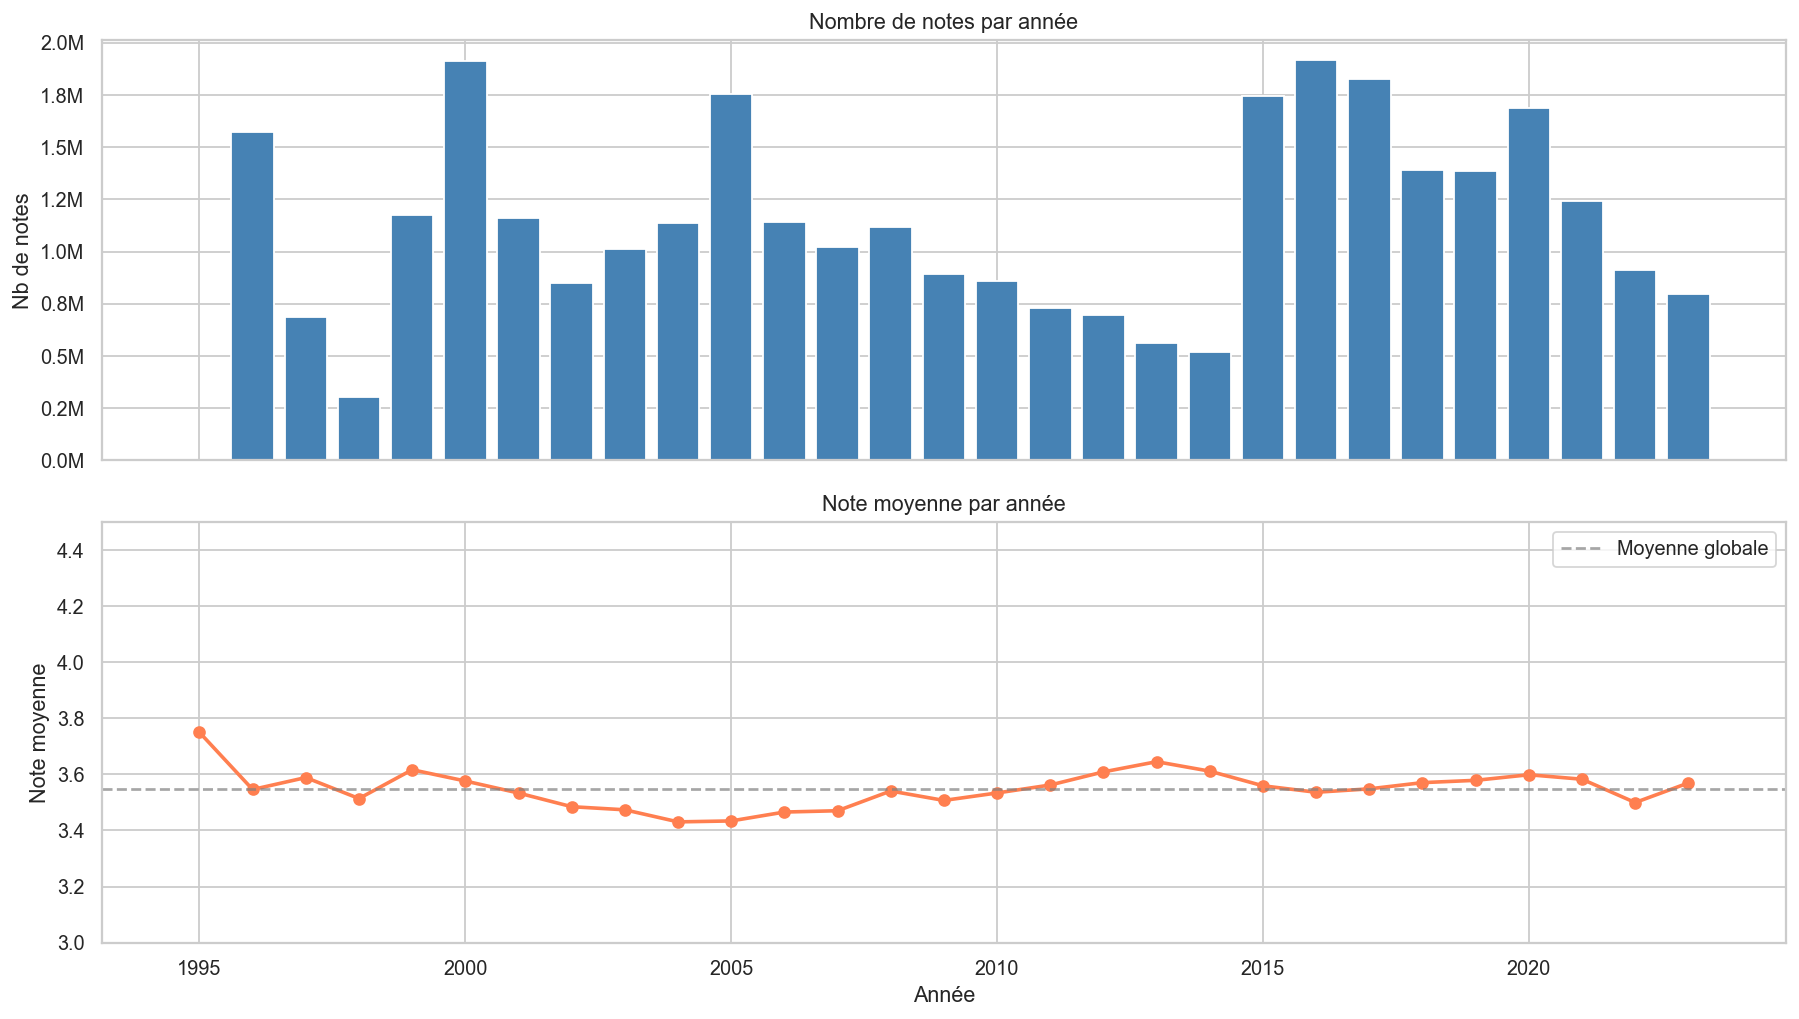

In [50]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(yearly["year"], yearly["nb_ratings"], color="steelblue")
axes[0].set_title("Nombre de notes par année")
axes[0].set_ylabel("Nb de notes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[1].plot(yearly["year"], yearly["avg_rating"], marker="o", color="coral", linewidth=2)
axes[1].axhline(y=yearly["avg_rating"].mean(), linestyle="--",
                color="gray", alpha=0.7, label="Moyenne globale")
axes[1].set_title("Note moyenne par année")
axes[1].set_ylabel("Note moyenne")
axes[1].set_xlabel("Année")
axes[1].legend()
axes[1].set_ylim(3.0, 4.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_evolution_temporelle.png", bbox_inches="tight")
plt.show()


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 10. Données financières & popularité TMDB
#
# Les données TMDB apportent des informations supplémentaires utiles
# pour mieux comprendre les films populaires et détecter des corrélations
# entre budget, revenus et note des spectateurs.


In [51]:
# ── Nettoyage : budget et revenue à 0 = données manquantes ────────────────────
movies_financial = (
    movies_enriched
    .filter(
        F.col("budget").isNotNull() & (F.col("budget") > 0) &
        F.col("revenue").isNotNull() & (F.col("revenue") > 0) &
        F.col("vote_average").isNotNull() & (F.col("vote_count") >= 20)
    )
    .withColumn("roi", (F.col("revenue") - F.col("budget")) / F.col("budget"))
    .withColumn("budget_M", F.col("budget") / 1e6)
    .withColumn("revenue_M", F.col("revenue") / 1e6)
)

print(f"Films avec données financières complètes : {movies_financial.count():,}")


Films avec données financières complètes : 9,940


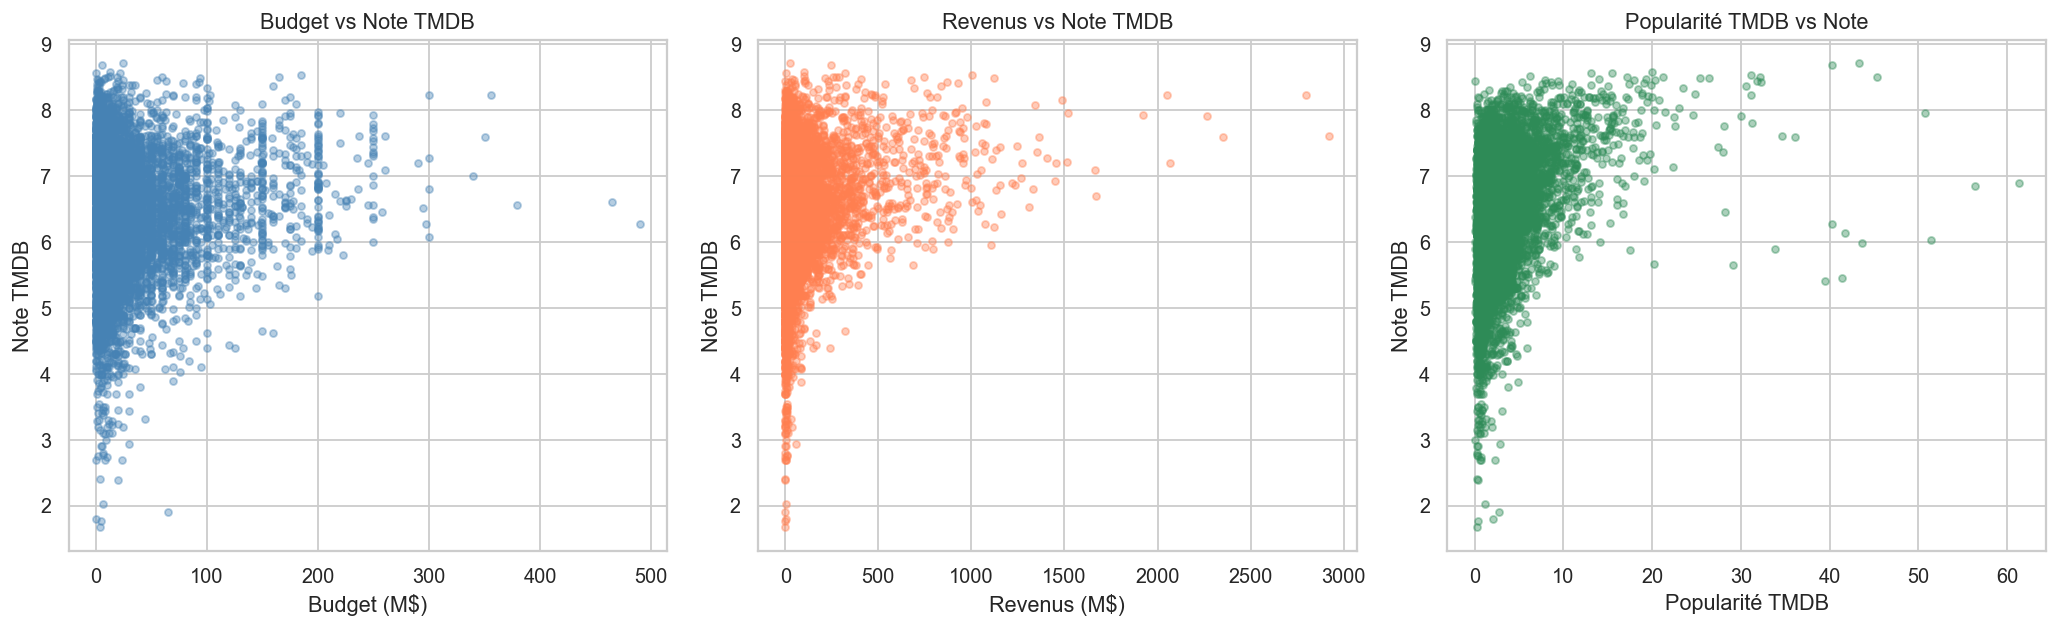

In [52]:
# ── Corrélation budget / note TMDB ────────────────────────────────────────────
fin_pd = movies_financial.select(
    "title_clean", "budget_M", "revenue_M", "roi",
    "vote_average", "vote_count", "popularity"
).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(fin_pd["budget_M"], fin_pd["vote_average"],
                alpha=0.4, s=15, color="steelblue")
axes[0].set_title("Budget vs Note TMDB")
axes[0].set_xlabel("Budget (M$)")
axes[0].set_ylabel("Note TMDB")

axes[1].scatter(fin_pd["revenue_M"], fin_pd["vote_average"],
                alpha=0.4, s=15, color="coral")
axes[1].set_title("Revenus vs Note TMDB")
axes[1].set_xlabel("Revenus (M$)")
axes[1].set_ylabel("Note TMDB")

axes[2].scatter(fin_pd["popularity"], fin_pd["vote_average"],
                alpha=0.4, s=15, color="seagreen")
axes[2].set_title("Popularité TMDB vs Note")
axes[2].set_xlabel("Popularité TMDB")
axes[2].set_ylabel("Note TMDB")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_financier_tmdb.png", bbox_inches="tight")
plt.show()


In [ ]:
# ── Top 10 films au Return on Investment (ROI) le plus élevé ─────────────────────────────────────────
BUDGET_MIN_M = 0.001  # 10 000$ minimum (élimine tous les placeholders 1$→58$)

top_roi = (
    fin_pd
    .query("budget_M >= @BUDGET_MIN_M and revenue_M > 0")
    .sort_values("roi", ascending=False)
    .head(10)
    [["title_clean", "budget_M", "revenue_M", "roi", "vote_average"]]
    .assign(
        roi       = lambda df: df["roi"].round(1),
        budget_M  = lambda df: df["budget_M"].round(3),
        revenue_M = lambda df: df["revenue_M"].round(1),
    )
)
print(top_roi.to_string(index=False))


                                         title_clean  budget_M  revenue_M     roi  vote_average
                                 Paranormal Activity     0.015      193.4 12889.4         6.044
                            Blair Witch Project, The     0.060      248.6  4143.0         6.364
Fist of Fury (Chinese Connection, The) (Jing wu men)     0.100      100.0   999.0         7.200
                              Brothers McMullen, The     0.025       19.3   772.1         6.025
                                        Animal World     0.125       69.9   558.1         7.000
                                             Mr. Six     0.250      139.2   555.8         6.800
                                 One Cut of the Dead     0.052       27.6   525.5         7.629
                                      Pink Flamingos     0.012        6.0   499.0         6.165
                                    Secret Superstar     0.286      137.4   479.0         7.268
                                        

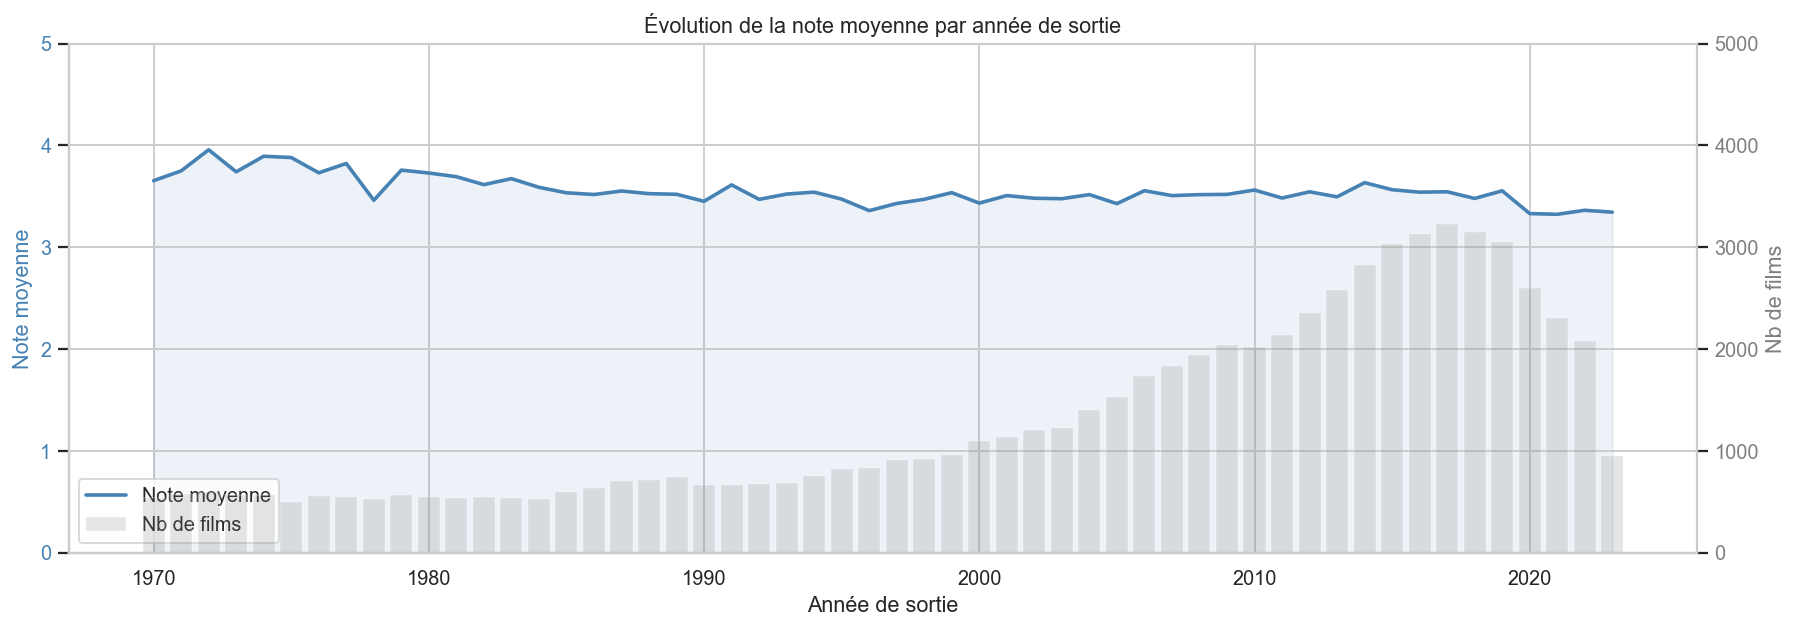

In [76]:
# ── Notes moyennes par année de sortie ───────────────────────────────────────
ratings_by_year = (
    movies_enriched
    .select("movieId", "year_movielens")
    .filter(F.col("year_movielens").isNotNull())
    .filter(F.col("year_movielens") >= 1970)   # évite les vieux films sous-représentés
    .join(ratings.select("movieId", "rating"), on="movieId", how="inner")
    .groupBy("year_movielens")
    .agg(
        F.mean("rating").alias("avg_rating"),
        F.count("rating").alias("nb_ratings"),
        F.countDistinct("movieId").alias("nb_films")
    )
    .orderBy("year_movielens")
    .toPandas()
)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Note moyenne (axe principal)
ax1.plot(ratings_by_year["year_movielens"], ratings_by_year["avg_rating"],
         color="steelblue", linewidth=2, label="Note moyenne")
ax1.fill_between(ratings_by_year["year_movielens"], ratings_by_year["avg_rating"],
                 alpha=0.1, color="steelblue")
ax1.set_ylabel("Note moyenne", color="steelblue")
ax1.set_ylim(0, 5)
ax1.tick_params(axis="y", labelcolor="steelblue")

# Nb de films (axe secondaire) — contexte sur la représentativité
ax2 = ax1.twinx()
ax2.bar(ratings_by_year["year_movielens"], ratings_by_year["nb_films"],
        alpha=0.2, color="grey", label="Nb de films")
ax2.set_ylabel("Nb de films", color="grey")
ax2.set_ylim(0, 5000)
ax2.tick_params(axis="y", labelcolor="grey")

ax1.set_xlabel("Année de sortie")
ax1.set_title("Évolution de la note moyenne par année de sortie")
ax1.spines[["top", "right"]].set_visible(False)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_notes_par_annee.png", bbox_inches="tight")
plt.show()


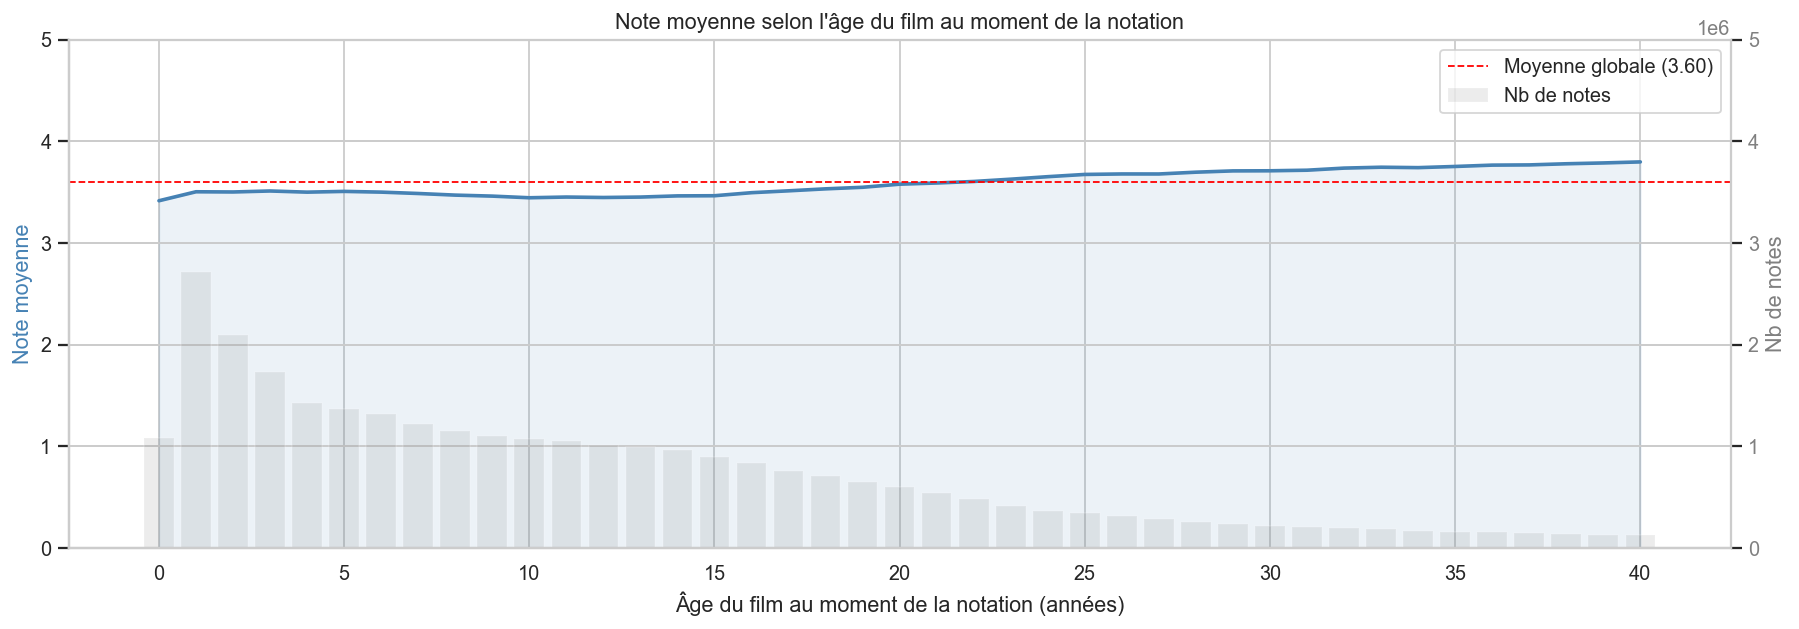

In [75]:
# ── Biais temporel : écart entre année de sortie et année de notation ─────────
from pyspark.sql.functions import year, to_timestamp

ratings_temporal = (
    ratings
    .withColumn("year_rated", year(to_timestamp(F.col("timestamp"))))
    .join(movies_enriched.select("movieId", "year_movielens"), on="movieId", how="inner")
    .filter(F.col("year_movielens").isNotNull())
    .withColumn("age_at_rating", F.col("year_rated") - F.col("year_movielens"))
    .filter((F.col("age_at_rating") >= 0) & (F.col("age_at_rating") <= 40))
    .groupBy("age_at_rating")
    .agg(
        F.mean("rating").alias("avg_rating"),
        F.count("rating").alias("nb_ratings")
    )
    .orderBy("age_at_rating")
    .toPandas()
)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(ratings_temporal["age_at_rating"], ratings_temporal["avg_rating"],
         color="steelblue", linewidth=2)
ax1.fill_between(ratings_temporal["age_at_rating"], ratings_temporal["avg_rating"],
                 alpha=0.1, color="steelblue")

# Ligne de référence : note moyenne globale
mean_global = ratings_temporal["avg_rating"].mean()
ax1.axhline(mean_global, color="red", linestyle="--", linewidth=1, label=f"Moyenne globale ({mean_global:.2f})")

ax2 = ax1.twinx()
ax2.bar(ratings_temporal["age_at_rating"], ratings_temporal["nb_ratings"],
        alpha=0.15, color="grey", label="Nb de notes")
ax2.set_ylabel("Nb de notes", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")
ax2.set_ylim(0, 5e6)

ax1.set_xlabel("Âge du film au moment de la notation (années)")
ax1.set_ylabel("Note moyenne", color="steelblue")
ax1.set_ylim(0, 5)
ax1.set_title("Note moyenne selon l'âge du film au moment de la notation")
ax1.spines[["top", "right"]].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_biais_temporel.png", bbox_inches="tight")
plt.show()


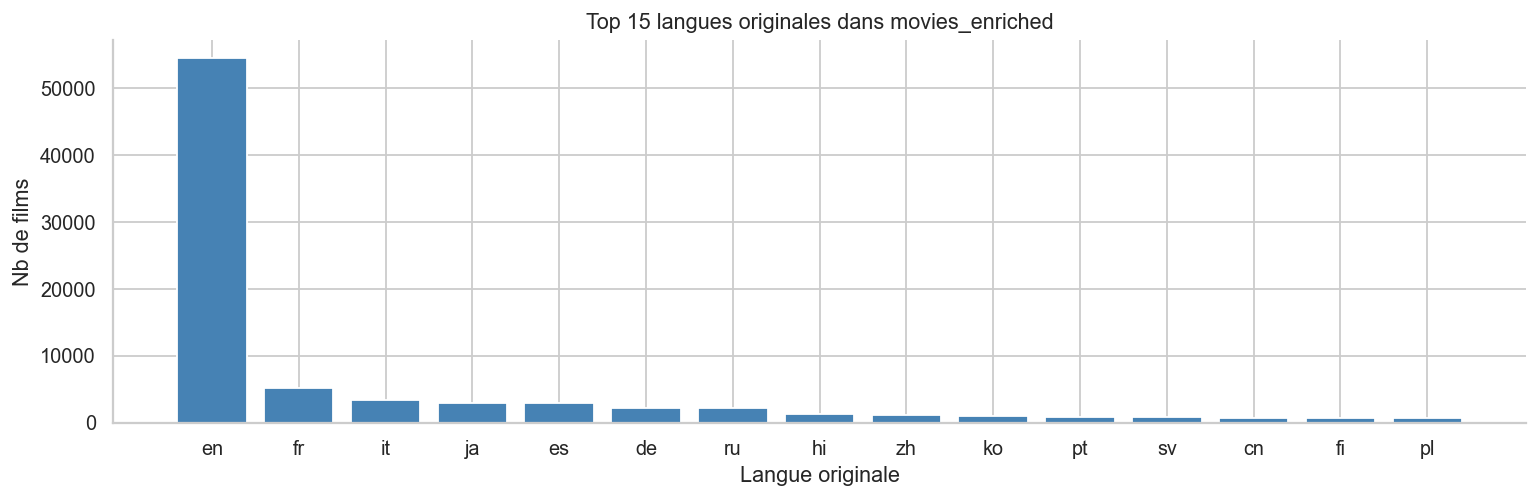

In [80]:
# ── Analyse original_lang ─────────────────────────────────────────────────────
lang_stats = (
    movies_enriched
    .groupBy("original_lang")
    .agg(F.count("movieId").alias("nb_films"))
    .orderBy(F.col("nb_films").desc())
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lang_stats["original_lang"], lang_stats["nb_films"],
       color="steelblue", edgecolor="white")
ax.set_xlabel("Langue originale")
ax.set_ylabel("Nb de films")
ax.set_title("Top 15 langues originales dans movies_enriched")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/11_langues.png", bbox_inches="tight")
plt.show()


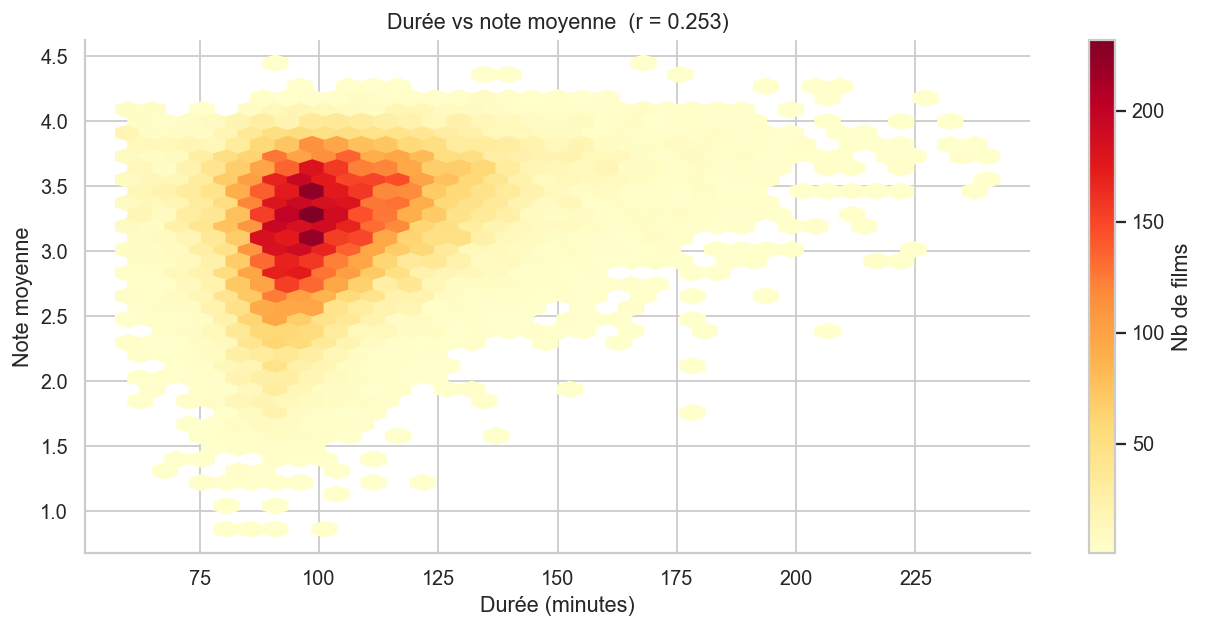

Corrélation de Pearson : 0.2531


In [82]:
# ── Runtime vs note moyenne ───────────────────────────────────────────────────
runtime_pd = (
    movies_enriched
    .select("movieId", "runtime")
    .filter(F.col("runtime").isNotNull())
    .filter((F.col("runtime") >= 60) & (F.col("runtime") <= 240))
    .join(ratings_per_movie.select("movieId", "avg_rating", "nb_ratings"), on="movieId")
    .filter(F.col("nb_ratings") >= SEUIL)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hexbin(runtime_pd["runtime"], runtime_pd["avg_rating"],
          gridsize=35, cmap="YlOrRd", mincnt=1)

plt.colorbar(ax.collections[0], ax=ax, label="Nb de films")

corr_val = runtime_pd["runtime"].corr(runtime_pd["avg_rating"])
ax.set_xlabel("Durée (minutes)")
ax.set_ylabel("Note moyenne")
ax.set_title(f"Durée vs note moyenne  (r = {corr_val:.3f})")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_runtime_note.png", bbox_inches="tight")
plt.show()
print(f"Corrélation de Pearson : {corr_val:.4f}")


# ── 📝 MARKDOWN ──────────────────────────────────────────────────────────────
# ## 11. Synthèse & Conclusions
#
# | Dimension            | Observation clé                                      |
# |----------------------|------------------------------------------------------|
# | **Sparsité**         | Matrice très creuse → ALS est bien adapté            |
# | **Distribution**     | Biais positif : la majorité des notes ≥ 3.5          |
# | **Cold start users** | X% des users ont noté < 20 films                     |
# | **Cold start films** | X% des films ont < 5 notes                           |
# | **Genre populaire**  | Drama, Comedy et Action dominent en volume           |
# | **Genre mieux noté** | Film-Noir, Documentary et War ressortent             |
# | **Évolution**        | Activité croissante, note stable autour de 3.5–3.8  |
# | **TMDB**             | Peu de corrélation budget/note → qualité ≠ argent   |
#
# **→ Pour la modélisation ALS**, on retiendra un seuil minimal de notes
#    par utilisateur et par film pour limiter le cold start.
# **→ Pour la recommandation contenu**, les champs `overview` et `keywords`
#    TMDB enrichiront le TF-IDF au-delà des seuls genres MovieLens.


In [77]:
# ── Sauvegarde du résumé statistique ─────────────────────────────────────────
summary = {
    "nb_ratings":   nb_ratings,
    "nb_users":     nb_users,
    "nb_movies":    nb_movies_r,
    "sparsity_pct": round(sparsity * 100, 4),
    "avg_rating":   round(ratings.select(F.mean("rating")).collect()[0][0], 3),
}
pd.DataFrame([summary]).to_csv(f"{OUTPUT_DIR}/eda_summary.csv", index=False)
print("✅ Résumé sauvegardé →", f"{OUTPUT_DIR}/eda_summary.csv")


✅ Résumé sauvegardé → ../outputs/eda_summary.csv
